In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [2]:
import torch
from custom_vision_transformer import vit_custom
from training_utils import get_data_loaders
from types import SimpleNamespace
import matplotlib.pyplot as plt

In [3]:
params = SimpleNamespace(
    gpu_idx=0,
    num_classes=100,
    img_size=224,
    batch_size=32,
)

In [4]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 3


/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU2 Quadro P400 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
Quadro P400 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Quadro P400 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


Device: cuda:0 NVIDIA GeForce RTX 2080


In [12]:
model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, attention_bias=True).to(device)
checkpoint = torch.load("./training_checkpoints/checkpoint1/vit_custom_epoch_10.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval();

In [13]:
train_loader, val_loader = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

Difference with top-10 tokens over 16 batches: 0.436985, Accuracy: 0.3262, Top-5 Accuracy: 0.6270
Difference with top-20 tokens over 16 batches: 0.340276, Accuracy: 0.3438, Top-5 Accuracy: 0.6191
Difference with top-30 tokens over 16 batches: 0.278716, Accuracy: 0.3828, Top-5 Accuracy: 0.6758
Difference with top-40 tokens over 16 batches: 0.243699, Accuracy: 0.3438, Top-5 Accuracy: 0.6484
Difference with top-50 tokens over 16 batches: 0.207255, Accuracy: 0.4004, Top-5 Accuracy: 0.6465
Difference with top-60 tokens over 16 batches: 0.183481, Accuracy: 0.4121, Top-5 Accuracy: 0.6973
Difference with top-70 tokens over 16 batches: 0.163271, Accuracy: 0.4316, Top-5 Accuracy: 0.6992
Difference with top-80 tokens over 16 batches: 0.143244, Accuracy: 0.3691, Top-5 Accuracy: 0.6543
Difference with top-90 tokens over 16 batches: 0.127646, Accuracy: 0.3848, Top-5 Accuracy: 0.7012


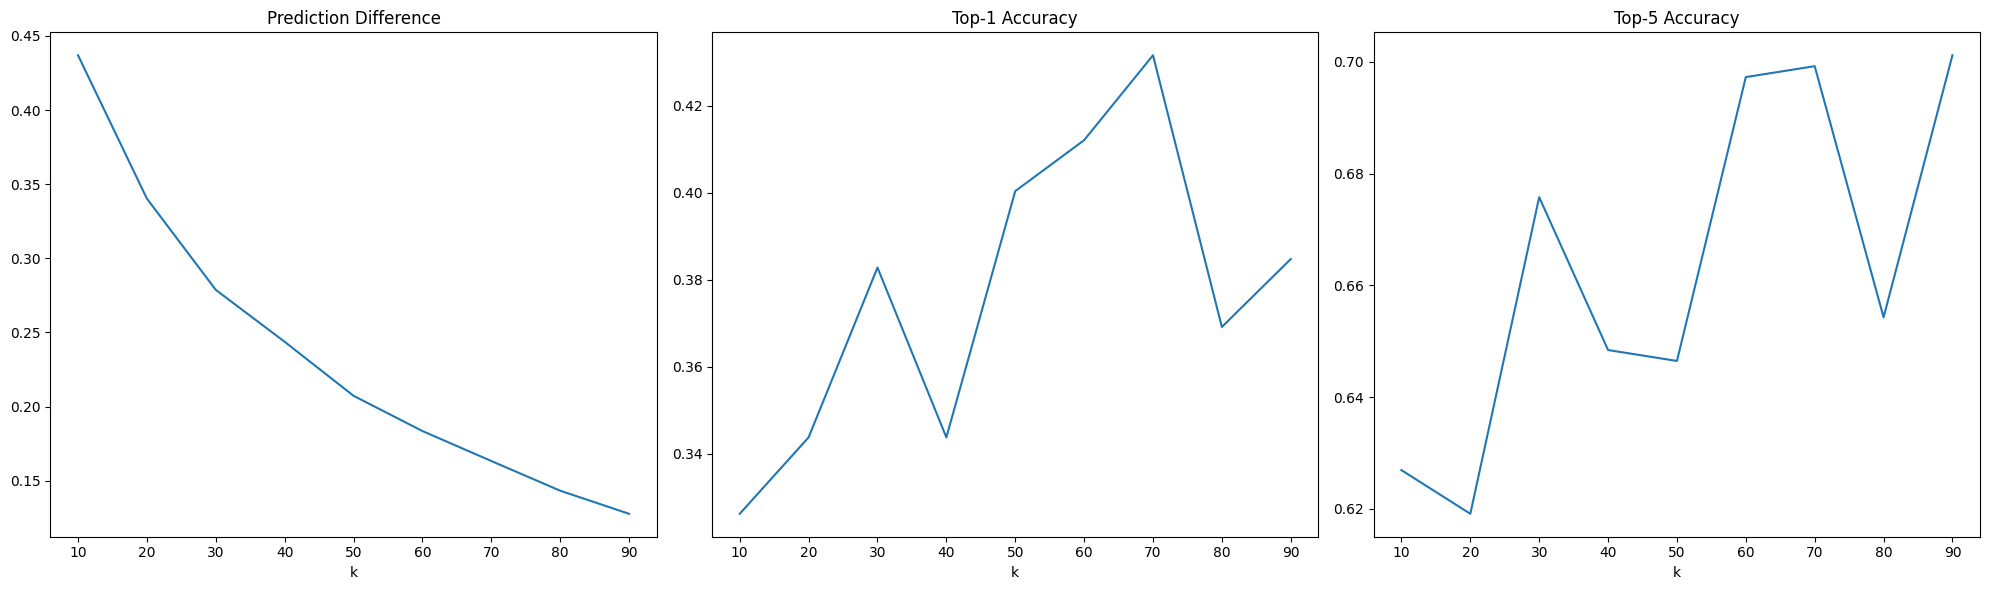

In [ ]:
def get_diff(k, n_batches=10):
    for module in model.modules():  # Nettoyer tous les hooks existants sur tous les modules
        module._forward_hooks.clear()

    def hook(module, input, output):
        out, attn = output  # (B, H, T, D), (B, H, T, T)
        x = input[0]  # (B, T, D)
        B, T, C = x.shape

        # --- recompute V ---
        qkv = module.qkv(x).reshape(B, T, 3, module.num_heads, module.head_dim)
        _, _, v = qkv.unbind(2)   # (B, T, H, D)
        v = v.transpose(1, 2)     # (B, H, T, D)

        # --- mask tokens (keep top-k tokens per head) ---
        token_importance = attn.mean(dim=-2)  # (B, H, T)
        mask = torch.ones_like(token_importance, dtype=torch.bool)
        k_eff = min(k, T)
        for b in range(B):
            for h in range(module.num_heads):
                topk_idx = torch.topk(token_importance[b, h], k=k_eff).indices
                mask[b, h, topk_idx] = 0

        attn = attn.clone()
        attn[mask.unsqueeze(-2).expand(-1, -1, T, -1)] = 0.0
        attn = attn / (attn.sum(dim=-1, keepdim=True) + 1e-8)

        # --- recompute output ---
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, T, C)
        out = module.out_proj(out)

        return out, attn

    total_samples = 0
    diff_weighted_sum = 0.0
    correct1 = 0
    correct5 = 0

    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(val_loader):
            if batch_idx >= n_batches:
                break

            imgs = imgs.to(device)
            labels = labels.to(device)

            # Baseline predictions without masking hooks
            preds_ref = model(imgs)

            # Masked predictions with hooks enabled
            handles = []
            for name, module in model.named_modules():
                if name.endswith(".attention"):
                    handles.append(module.register_forward_hook(hook))

            preds_masked = model(imgs)

            for handle in handles:
                handle.remove()

            batch_size = labels.size(0)
            total_samples += batch_size

            batch_diff = torch.abs(preds_ref - preds_masked).mean().item()
            diff_weighted_sum += batch_diff * batch_size

            correct1 += (preds_masked.argmax(dim=-1) == labels).sum().item()
            correct5 += (preds_masked.topk(5, dim=-1).indices == labels.unsqueeze(-1)).any(dim=-1).sum().item()

    if total_samples == 0:
        raise ValueError("No samples were evaluated. Increase n_batches or check val_loader.")

    diff = diff_weighted_sum / total_samples
    accuracy_masked = correct1 / total_samples
    top5acc_masked = correct5 / total_samples

    print(
        f"Difference with top-{k} tokens over {n_batches} batches: {diff:.6f}, "
        f"Accuracy: {accuracy_masked:.4f}, Top-5 Accuracy: {top5acc_masked:.4f}"
    )

    return diff, accuracy_masked, top5acc_masked

N_BATCHES = 16
ks = [10 * i for i in range(1, 20)]
diffs, accuracies, top5_accuracies = zip(*[get_diff(k, n_batches=N_BATCHES) for k in ks])

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.plot(ks, diffs, label='Mean Absolute Difference')
plt.xlabel('k')
plt.title('Prediction Difference')

plt.subplot(1, 3, 2)
plt.plot(ks, accuracies, label='Accuracy')
plt.xlabel('k')
plt.title('Top-1 Accuracy')

plt.subplot(1, 3, 3)
plt.plot(ks, top5_accuracies, label='Top-5 Accuracy')
plt.xlabel('k')
plt.title('Top-5 Accuracy')

plt.tight_layout()
plt.show()